In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Shared "paper" look, kept in sync with the other benchmarking notebooks (Statistic Stores.ipynb,
# StoreWriterOverhead.ipynb): white background, dotted grid drawn per axis, and only the left/bottom
# spines. "ticks" (not "whitegrid") is what lets the despine in style_axis leave a clean L-shaped
# frame instead of a boxed, solid-gridded panel.
sns.set_theme(style="ticks", context="paper", palette="colorblind")

PAPER_RC = {
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "pdf.fonttype": 42,  # TrueType, not Type-3: ACM/IEEE preflight rejects Type-3
    "ps.fonttype": 42,
}
COL_W, FULL_W = 3.3, 7.0

# Ceiling is WORKLOAD-DEPENDENT and must match the mix being plotted, or the load-vs-capacity
# annotation lies. Measured unpaced on amd7950x3d, 16 worker threads:
#   10 Q2 queries alone                    -> 22.5 Mtup/s   (all sliding-window aggregation)
#   10 Q2 + 50 histogram queries           -> 28.8 Mtup/s   (4.8 analytical + 24.0 statistic)
# Independently reconfirmed by the saturated j=100 column, which delivers 28.8-29.2 Mtup/s at every
# k. Using the pure-Q2 figure here would overstate how close the grid runs to saturation.
CEILING_MTPS = 28.8

PALETTE = sns.color_palette("colorblind")
MARKERS = ["o", "s", "^", "D", "v"]
RATE_STYLE = {100_000: "-", 350_000: "--"}

FIGURES = {}


def style_axis(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, linestyle=":", linewidth=0.5, alpha=0.6)
    ax.tick_params(length=2, width=0.6)
    sns.despine(ax=ax)


def rate_label(rate):
    return f"{rate / 1000:.0f}k tup/s per query"


def _rate_tag(rate):
    return f"{rate // 1000}k"

In [2]:
### ONE file, one sweep. run_statistic_grid.py writes a single results_statistic_grid.csv covering
### every (rate, k, j, run) point, so analysing a sweep is a one-file download:
###   scp <host>:<output-dir>/results_statistic_grid.csv .
### Point RESULTS_CSV somewhere else to plot a different sweep. Deliberately NOT a directory glob:
### merging sweeps silently double-counted cells that more than one run had measured.
RESULTS_CSV = "results_statistic_grid.csv"

if not os.path.exists(RESULTS_CSV):
    raise FileNotFoundError(
        f"{os.path.abspath(RESULTS_CSV)} not found. Download one sweep's results CSV to this "
        f"directory, or set RESULTS_CSV to its path.")

raw = pd.read_csv(RESULTS_CSV).assign(source=os.path.basename(RESULTS_CSV))
print("loaded:", os.path.abspath(RESULTS_CSV), f"({len(raw)} rows)")

loaded: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/results_statistic_grid.csv (810 rows)


In [3]:
df = raw.copy()
_total = len(df)

# Drop only genuinely broken points. A point that merely lost a query from the throughput listener
# is still usable, because the headline is median-per-query — that is why it was chosen.
_fatal = df["issue"].str.contains("exception|buffer exhaustion|no analytical throughput",
                                  case=False, na=False)
df = df[~_fatal].copy()

for col in ["analytical_throughput_tps", "analytical_throughput_median_tps",
            "statistic_throughput_tps", "offered_tps", "analytical_offered_tps"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in ["num_analytical_queries", "num_statistic_queries", "run_idx",
            "num_analytical_measured", "num_statistic_measured", "tuples_per_sec_per_query"]:
    df[col] = df[col].astype(int)

# Sweeps recorded before the reference arms existed have no analytical_query column, and every one
# of their queries was a Q2 window aggregation.
if "analytical_query" not in df.columns:
    df["analytical_query"] = "window"
df["analytical_query"] = df["analytical_query"].fillna("window")

KEY = ["tuples_per_sec_per_query", "num_analytical_queries", "num_statistic_queries",
       "analytical_query", "run_idx"]
_dupes = df[df.duplicated(KEY, keep=False)]
if len(_dupes):
    print(f"WARNING: {len(_dupes)} rows share a (rate, k, j, run) key across files — the merged "
          f"directories overlap, so means are weighted by however many copies each point has:")
    print(_dupes[KEY + ["source"]].to_string(index=False))

# Headline: median per analytical query scaled to the workload, NOT the raw sum. A query that
# deploys late can have all its windows land inside the warm-up and vanish from the sum, dropping it
# by 1/k — which at these grid sizes is far larger than any effect being measured, and would
# masquerade as overhead. The median is unaffected by one missing sample.
df["analytical_mtps"] = (df["analytical_throughput_median_tps"]
                         * df["num_analytical_queries"]) / 1e6
df["analytical_sum_mtps"] = df["analytical_throughput_tps"] / 1e6
df["statistic_mtps"] = df["statistic_throughput_tps"] / 1e6
df["sustained_frac"] = (df["analytical_throughput_median_tps"] * df["num_analytical_queries"]
                        / df["analytical_offered_tps"])
df["statistic_sustained_frac"] = (df["statistic_throughput_tps"]
                                  / (df["tuples_per_sec_per_query"]
                                     * df["num_statistic_queries"]).replace(0, np.nan))
df["total_offered_mtps"] = df["offered_tps"] / 1e6
# Achieved total uses the SUM on both sides, not the median headline: this is a capacity question,
# and capacity is what actually came out of the machine.
df["total_achieved_mtps"] = df["analytical_sum_mtps"] + df["statistic_mtps"]
df["load_pct_of_ceiling"] = df["total_offered_mtps"] / CEILING_MTPS * 100
df["saturated"] = df["total_offered_mtps"] > CEILING_MTPS

print(f"\n{len(df)}/{_total} points usable")
print("rates:", sorted(df["tuples_per_sec_per_query"].unique()), "tup/s per query")
print("k values:", sorted(df["num_analytical_queries"].unique()))
print("j values:", sorted(df["num_statistic_queries"].unique()))
print(f"offered load spans {df['total_offered_mtps'].min():.2f}-"
      f"{df['total_offered_mtps'].max():.2f} Mtup/s "
      f"({df['load_pct_of_ceiling'].min():.1f}-{df['load_pct_of_ceiling'].max():.1f}% of the "
      f"{CEILING_MTPS} Mtup/s ceiling); {int(df['saturated'].sum())} points are above it")

_incomplete = df[df["num_analytical_measured"] != df["num_analytical_queries"]]
if len(_incomplete):
    print(f"\nWARNING: {len(_incomplete)} point(s) measured fewer analytical queries than "
          f"submitted — the median headline is unaffected, but watch for this becoming systematic "
          f"at high j:")
    print(_incomplete[KEY + ["num_analytical_measured"]].to_string(index=False))
df.head()


810/810 points usable
rates: [np.int64(100000), np.int64(200000), np.int64(350000)] tup/s per query
k values: [np.int64(1), np.int64(2), np.int64(5), np.int64(10), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(150), np.int64(200)]
j values: [np.int64(0), np.int64(2), np.int64(10), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(150), np.int64(200)]
offered load spans 0.10-73.50 Mtup/s (0.3-255.2% of the 28.8 Mtup/s ceiling); 160 points are above it


,num_analytical_queries,num_statistic_queries,analytical_query,run_idx,num_worker_threads,window_size_sec,window_advance_sec,statistic_window_sec,job_domain,events_per_sec,...,source,analytical_mtps,analytical_sum_mtps,statistic_mtps,sustained_frac,statistic_sustained_frac,total_offered_mtps,total_achieved_mtps,load_pct_of_ceiling,saturated
0,1,0,window,0,16,60,1,10,10000,100000,...,results_statistic_grid.csv,0.099999,0.099999,0.0,0.999989,NaN,0.1,0.099999,0.347222,False
1,1,0,window,1,16,60,1,10,10000,100000,...,results_statistic_grid.csv,0.099995,0.099995,0.0,0.999953,NaN,0.1,0.099995,0.347222,False
2,1,0,window,2,16,60,1,10,10000,100000,...,results_statistic_grid.csv,0.100006,0.100006,0.0,1.000055,NaN,0.1,0.100006,0.347222,False
3,1,0,window,3,16,60,1,10,10000,100000,...,results_statistic_grid.csv,0.099999,0.099999,0.0,0.999992,NaN,0.1,0.099999,0.347222,False
4,1,0,window,4,16,60,1,10,10000,100000,...,results_statistic_grid.csv,0.099997,0.099997,0.0,0.999969,NaN,0.1,0.099997,0.347222,False


In [4]:
### analytical_query is part of the key: without it the window and filter reference arms, which
### share (rate, k, j=0), would be averaged into a single meaningless line.
agg = (df.groupby(["tuples_per_sec_per_query", "num_analytical_queries", "num_statistic_queries",
                   "analytical_query"])
         .agg(mean_mtps=("analytical_mtps", "mean"),
              std_mtps=("analytical_mtps", "std"),
              mean_sustained=("sustained_frac", "mean"),
              std_sustained=("sustained_frac", "std"),
              mean_stat_sustained=("statistic_sustained_frac", "mean"),
              mean_stat_mtps=("statistic_mtps", "mean"),
              mean_offered_mtps=("total_offered_mtps", "mean"),
              mean_achieved_mtps=("total_achieved_mtps", "mean"),
              mean_load_pct=("load_pct_of_ceiling", "mean"),
              saturated=("saturated", "first"),
              runs=("analytical_mtps", "size"))
         .reset_index())
agg[["std_mtps", "std_sustained"]] = agg[["std_mtps", "std_sustained"]].fillna(0.0)

# Relative to that (rate, k) cell's own j=0 baseline, so each series answers "what did monitoring
# cost THIS workload" rather than mixing workload sizes or rates together.
### Restricted to the window shape: with the filter arm present there are two j=0 rows per (rate, k)
### and the index would no longer be unique, so every lookup below would return a Series.
_base = (agg[(agg["num_statistic_queries"] == 0) & (agg["analytical_query"] == "window")]
         .set_index(["tuples_per_sec_per_query", "num_analytical_queries"])["mean_mtps"])
agg["pct_of_baseline"] = agg.apply(
    lambda r: r["mean_mtps"] / _base[(r["tuples_per_sec_per_query"],
                                      r["num_analytical_queries"])] * 100, axis=1)
# Same denominator as pct_of_baseline, so the error band is in the same units as the line it wraps.
agg["pct_std"] = agg.apply(
    lambda r: r["std_mtps"] / _base[(r["tuples_per_sec_per_query"],
                                     r["num_analytical_queries"])] * 100, axis=1)
### The two reference arms, both at j=0 — no statistics running, only k analytical queries:
###   window  ClusterMonitoring Q2, the grid's own workload. Lower limit. The grid's j=0 cells ARE
###           this arm at k=1,5,10, so those come free as the line's left anchors.
###   filter  the same query without the sliding window and GROUP BY, keeping Q2's predicate so 25%
###           of the stream still flows through to a Void sink.
### Note "filter" is NOT a strict upper limit: the sink discards, but the pipeline still materialises
### every surviving tuple into an output buffer first, which at 150 queries is ~7.5 Mtup/s of copying
### — more per tuple than a histogram build costs, which is why this arm can sit BELOW the grid.
### The runner also has an "ingest" shape (predicate matches nothing, so nothing is materialised)
### that is the true floor; swap it in here, or add it as a third entry, once it has been measured.
### The band between them is what a 60 s sliding aggregation costs, and it is the yardstick the
### coloured lines' drop should be read against. Split BEFORE KS/JS are derived, so every other
### figure in this notebook keeps seeing exactly the three hue series it was built for.
MAIN_KS = [1, 5, 10]
REF_ARMS = [("window", "--", "x", "no statistics: stateful"),
            ("filter", ":", "+", "no statistics: stateless")]
base_arm = agg[agg["num_statistic_queries"] == 0].copy()
agg = agg[agg["num_analytical_queries"].isin(MAIN_KS) & (agg["analytical_query"] == "window")]

RATES = sorted(agg["tuples_per_sec_per_query"].unique())
KS = sorted(agg["num_analytical_queries"].unique())
JS = sorted(agg["num_statistic_queries"].unique())


def j_ticks(js, min_gap=0.08):
    """Thin the j tick LABELS. The swept values bunch at the low end (0, 10, 25 against a 200 range)
    and their labels overlap illegibly on a linear axis. Points still plot at their true positions —
    only some labels are dropped, so the axis stays quantitative rather than becoming categorical."""
    span = (max(js) - min(js)) or 1
    keep = [js[0]]
    for j in js[1:]:
        if (j - keep[-1]) / span >= min_gap:
            keep.append(j)
    if js[-1] not in keep:
        keep.append(js[-1])
    return keep


J_TICKS = j_ticks(JS)
agg

,tuples_per_sec_per_query,num_analytical_queries,num_statistic_queries,analytical_query,mean_mtps,std_mtps,mean_sustained,std_sustained,mean_stat_sustained,mean_stat_mtps,mean_offered_mtps,mean_achieved_mtps,mean_load_pct,saturated,runs,pct_of_baseline,pct_std
1,100000,1,0,window,0.099999,0.000004,0.999992,0.000039,NaN,0.000000,0.1,0.099999,0.347222,False,5,100.000000,0.003892
2,100000,1,2,window,0.099998,0.000005,0.999981,0.000054,1.000008,0.200002,0.3,0.300000,1.041667,False,5,99.998890,0.005390
3,100000,1,10,window,0.100001,0.000003,1.000011,0.000025,1.000000,1.000000,1.1,1.100001,3.819444,False,5,100.001895,0.002518
4,100000,1,50,window,0.099889,0.000244,0.998888,0.002441,0.999108,4.995539,5.1,5.095428,17.708333,False,5,99.889627,0.244102
5,100000,1,60,window,0.099919,0.000173,0.999190,0.001734,0.998383,5.990297,6.1,6.090216,21.180556,False,5,99.919785,0.173429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,350000,10,80,window,3.148834,0.010470,0.899667,0.002991,0.900296,25.208288,31.5,28.354999,109.375000,True,5,89.967489,0.299140
142,350000,10,90,window,2.852910,0.014154,0.815117,0.004044,0.814609,25.660197,35.0,28.509372,121.527778,True,5,81.512454,0.404407
143,350000,10,100,window,2.594528,0.015493,0.741294,0.004426,0.742518,25.988126,38.5,28.578751,133.680556,True,5,74.130041,0.442649
144,350000,10,150,window,1.777515,0.004732,0.507862,0.001352,0.508222,26.681636,56.0,28.455418,194.444444,True,5,50.786609,0.135214


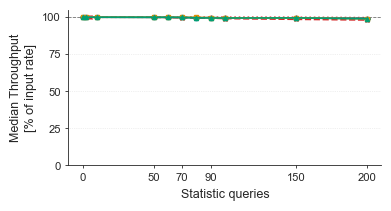

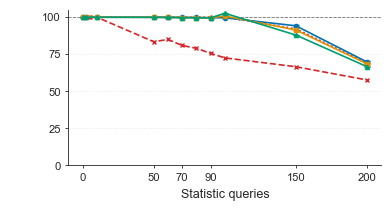

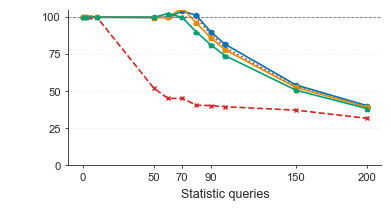

<Figure size 700x50 with 0 Axes>

In [5]:
### One figure PER RATE (filename carries the rate tag) instead of a single 1 x len(RATES) figure:
### the panels are placed side by side as LaTeX subfigures, so each needs its own PDF. The series are
### identical across rates, so they share ONE legend, emitted as its own legend-only figure that sits
### above the subfigure row.
# Per-figure geometry. Two of these sit side by side across the full text width now (not one row of
# three), so each gets half of FULL_W — a wider, flatter panel than the old FULL_W/len(RATES) box.
SUSTAINED_W, SUSTAINED_H = 4.0, 2.2

with sns.plotting_context("paper", rc=PAPER_RC):
    _legend_ax = None
    for rate in RATES:
        fig, ax = plt.subplots(figsize=(SUSTAINED_W, SUSTAINED_H))
        for idx, k in enumerate(KS):
            d = agg[(agg["tuples_per_sec_per_query"] == rate)
                    & (agg["num_analytical_queries"] == k)].sort_values("num_statistic_queries")
            ax.errorbar(d["num_statistic_queries"], d["mean_sustained"] * 100,
                        yerr=d["std_sustained"] * 100,
                        marker=MARKERS[idx % len(MARKERS)], color=PALETTE[idx], capsize=2,
                        label=f"{k}")
        # Same x axis, different quantity: on the reference arms x is an ANALYTICAL count. They answer
        # the objection the coloured lines cannot — is the drop what a STATISTIC query costs, or what
        # any extra query costs? Offered load differs from the coloured lines by k x rate (<= 6%), so
        # the arms read directly against them.
        for shape, ls, mk, lbl in REF_ARMS:
            b = base_arm[(base_arm["tuples_per_sec_per_query"] == rate)
                         & (base_arm["analytical_query"] == shape)].sort_values(
                             "num_analytical_queries")
            if b.empty:
                continue
            ### No error bars: the arms are references, not measurements under test — bars here
            ### only clutter the band the coloured lines are read against.
            ax.plot(b["num_analytical_queries"], b["mean_sustained"] * 100,
                    marker=mk, color="tab:red", linestyle=ls, label=lbl)
        ax.axhline(100, color="0.45", linewidth=0.6, linestyle="--", zorder=2)
        ax.set_xlabel("Statistic queries")
        ax.set_xticks(J_TICKS)
        #ax.set_title(rate_label(rate))
        ax.set_ylim(0, 105)
        # Fixed quarter ticks: the auto locator thins to 0/50/100 once savefig's tight bbox
        # shrinks the axes, so the panels and the saved PNG disagreed with the inline preview.
        ax.set_yticks(range(0, 101, 25))
        style_axis(ax)
        # Only the first rate SHOWS the y-label (the figures sit side by side under one caption),
        # but every rate carries it — transparent on the others. savefig's tight bbox measures
        # invisible-by-alpha text too, so all three PDFs come out the same size and the panels stay
        # aligned; dropping the label outright would make the first figure wider than the rest.
        ax.set_ylabel("Median Throughput\n[% of input rate]", alpha=1.0 if rate == RATES[0] else 0.0)
        fig.tight_layout()
        FIGURES[f"StatisticGrid_sustained_{_rate_tag(rate)}"] = fig
        # Source the shared legend from the rate whose panel drew the most series: an arm with no
        # data draws no line, and taking the first rate blindly could leave a hole in the strip.
        if _legend_ax is None or len(ax.get_legend_handles_labels()[0]) > len(_legend_ax.get_legend_handles_labels()[0]):
            _legend_ax = ax
        plt.show()

    # Legend-only figure, shared by the whole row, in TWO titled groups: the reference arms answer a
    # different question from the coloured k series (what does ANY extra query cost, vs what does a
    # statistic query cost), so mixing them into one strip under "Analytical queries" mislabels them.
    # The arms' shared "no statistics: " prefix moves into the group title. bbox_inches="tight"
    # (cell 11) crops the empty canvas away, so FULL_W only has to hold both groups side by side.
    if _legend_ax is not None:
        _handles, _labels = _legend_ax.get_legend_handles_labels()
        _arm_labels = {lbl for *_, lbl in REF_ARMS}
        _arms = [(h, l) for h, l in zip(_handles, _labels) if l in _arm_labels]
        _ks = [(h, l) for h, l in zip(_handles, _labels) if l not in _arm_labels]
        legfig = plt.figure(figsize=(FULL_W, 0.5))
        for _group, _title, _x in ((_arms, "Baseline", 0.30), (_ks, "Analytical queries", 0.72)):
            if not _group:
                continue
            legfig.legend([h for h, _ in _group], [l.split(": ", 1)[-1] for _, l in _group],
                          title=_title, ncol=len(_group), frameon=False,
                          loc="center", bbox_to_anchor=(_x, 0.5))
        FIGURES["StatisticGrid_sustained_legend"] = legfig
        plt.show()

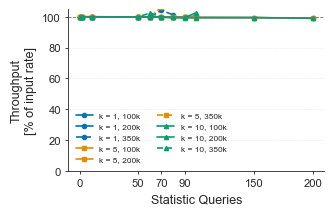

Below saturation, mean sustained fraction by j (all k, all rates pooled):
                       mean [%]  worst [%]  cells
num_statistic_queries                            
0                        99.999     99.998      9
2                        99.999     99.998      9
10                      100.000     99.998      9
50                       99.913     99.785      9
60                      100.187     99.836      9
70                      101.028     99.667      9
80                       99.932     99.569      7
90                       99.623     99.489      6
100                     100.286     99.467      6
150                      99.480     99.438      3
200                      99.040     98.982      3


In [6]:
sub = agg[~agg["saturated"]]

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(COL_W, 2.1))
    for idx, k in enumerate(KS):
        for rate in RATES:
            d = sub[(sub["num_analytical_queries"] == k)
                    & (sub["tuples_per_sec_per_query"] == rate)].sort_values("num_statistic_queries")
            if d.empty:
                continue
            ax.plot(d["num_statistic_queries"], d["mean_sustained"] * 100,
                    marker=MARKERS[idx % len(MARKERS)], color=PALETTE[idx],
                    linestyle=RATE_STYLE.get(rate, "-"),
                    label=f"k = {k}, {rate // 1000}k")
    ax.axhline(100, color="0.45", linewidth=0.6, linestyle="--", zorder=2)
    ax.set_xlabel("Statistic Queries")
    ax.set_ylabel("Throughput\n[% of input rate]")
    ax.set_xticks(J_TICKS)
    ax.set_ylim(0, 105)
    style_axis(ax)
    ax.legend(frameon=False, ncol=2, fontsize=6, loc="lower left")
    FIGURES["StatisticGrid_subsaturation"] = fig
    plt.show()

print("Below saturation, mean sustained fraction by j (all k, all rates pooled):")
print((sub.groupby("num_statistic_queries")["mean_sustained"].agg(["mean", "min", "count"]) * [100, 100, 1])
      .rename(columns={"mean": "mean [%]", "min": "worst [%]", "count": "cells"}).round(3).to_string())

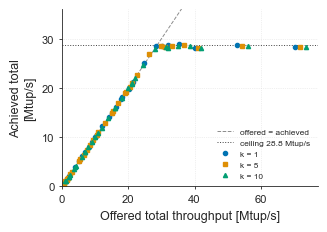

Saturated cells — achieved total should sit at the ceiling, and analytical/statistic should sustain the SAME fraction if degradation is proportional:
 tuples_per_sec_per_query  num_analytical_queries  num_statistic_queries  mean_offered_mtps  mean_achieved_mtps  analytical_pct  statistic_pct
                   200000                       1                    150              30.20               28.49           94.20          94.35
                   200000                       1                    200              40.20               28.12           69.78          69.96
                   200000                       5                    150              31.00               28.37           91.35          91.51
                   200000                       5                    200              41.00               28.18           68.59          68.72
                   200000                      10                    150              32.00               28.17           87.95        

In [7]:
with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(COL_W, 2.3))
    lim = agg["mean_offered_mtps"].max() * 1.05
    ax.plot([0, lim], [0, lim], color="0.55", linewidth=0.7, linestyle="--",
            label="offered = achieved", zorder=1)
    ax.axhline(CEILING_MTPS, color="0.25", linewidth=0.7, linestyle=":",
               label=f"ceiling {CEILING_MTPS} Mtup/s", zorder=1)
    for idx, k in enumerate(KS):
        d = agg[agg["num_analytical_queries"] == k].sort_values("mean_offered_mtps")
        ax.plot(d["mean_offered_mtps"], d["mean_achieved_mtps"],
                marker=MARKERS[idx % len(MARKERS)], color=PALETTE[idx],
                linestyle="none", label=f"k = {k}")
    ax.set_xlabel("Offered total throughput [Mtup/s]")
    ax.set_ylabel("Achieved total\n[Mtup/s]")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, CEILING_MTPS * 1.25)
    style_axis(ax, grid_axis="both")
    ax.legend(frameon=False, fontsize=6, loc="lower right")
    FIGURES["StatisticGrid_capacity"] = fig
    plt.show()

_sat = agg[agg["saturated"]]
if len(_sat):
    print("Saturated cells — achieved total should sit at the ceiling, and analytical/statistic "
          "should sustain the SAME fraction if degradation is proportional:")
    print(_sat.assign(analytical_pct=lambda d: d["mean_sustained"] * 100,
                      statistic_pct=lambda d: d["mean_stat_sustained"] * 100)
          [["tuples_per_sec_per_query", "num_analytical_queries", "num_statistic_queries",
            "mean_offered_mtps", "mean_achieved_mtps", "analytical_pct", "statistic_pct"]]
          .round(2).to_string(index=False))

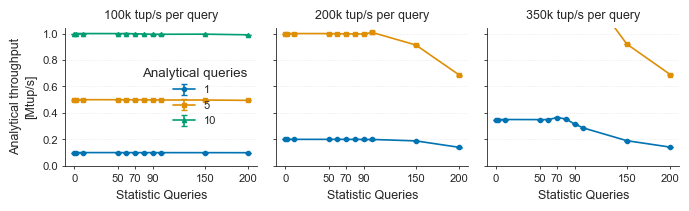

In [8]:
with sns.plotting_context("paper", rc=PAPER_RC):
    fig, axes = plt.subplots(1, len(RATES), figsize=(FULL_W, 2.2), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, rate in zip(axes, RATES):
        for idx, k in enumerate(KS):
            d = agg[(agg["tuples_per_sec_per_query"] == rate)
                    & (agg["num_analytical_queries"] == k)].sort_values("num_statistic_queries")
            ax.errorbar(d["num_statistic_queries"], d["mean_mtps"], yerr=d["std_mtps"],
                        marker=MARKERS[idx % len(MARKERS)], color=PALETTE[idx], capsize=2,
                        label=f"{k}")
        ax.set_xlabel("Statistic Queries")
        ax.set_xticks(J_TICKS)
        ax.set_title(rate_label(rate))
        ax.set_ylim(bottom=0)
        style_axis(ax)
    axes[0].set_ylabel("Analytical throughput\n[Mtup/s]")
    axes[0].legend(frameon=False, title="Analytical queries")
    fig.tight_layout()
    FIGURES["StatisticGrid_throughput"] = fig
    plt.show()

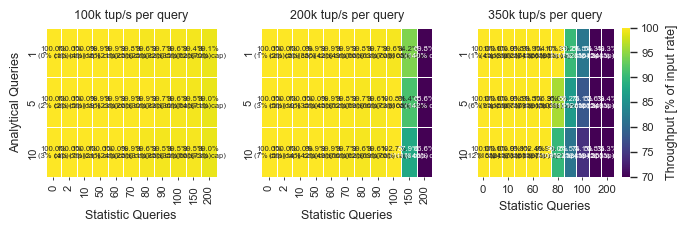

In [9]:
with sns.plotting_context("paper", rc=PAPER_RC):
    fig, axes = plt.subplots(1, len(RATES), figsize=(FULL_W, 2.4))
    axes = np.atleast_1d(axes)
    for n, (ax, rate) in enumerate(zip(axes, RATES)):
        a = agg[agg["tuples_per_sec_per_query"] == rate]
        pivot = a.pivot(index="num_analytical_queries", columns="num_statistic_queries",
                        values="mean_sustained") * 100
        load = a.pivot(index="num_analytical_queries", columns="num_statistic_queries",
                       values="mean_load_pct")
        labels = (pivot.round(1).astype(str) + "%\n("
                  + load.round(0).astype(int).astype(str) + "% cap)")
        sns.heatmap(pivot, annot=labels, fmt="", cmap="viridis", vmin=70, vmax=100,
                    linewidths=0.5, linecolor="white", ax=ax,
                    cbar=(n == len(RATES) - 1),
                    cbar_kws={"label": "Throughput [% of input rate]"}, annot_kws={"fontsize": 5.5})
        ax.set_xlabel("Statistic Queries")
        ax.set_ylabel("Analytical Queries" if n == 0 else "")
        ax.set_title(rate_label(rate))
        ax.tick_params(length=2, width=0.6)
    fig.tight_layout()
    FIGURES["StatisticGrid_heatmap"] = fig
    plt.show()

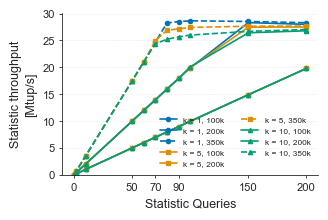

 tuples_per_sec_per_query  num_analytical_queries  num_statistic_queries  runs  mean_mtps  std_mtps  mean_sustained  mean_load_pct  pct_of_baseline
                   100000                       1                      0     5   0.099999  0.000004        0.999992       0.347222       100.000000
                   100000                       1                      2     5   0.099998  0.000005        0.999981       1.041667        99.998890
                   100000                       1                     10     5   0.100001  0.000003        1.000011       3.819444       100.001895
                   100000                       1                     50     5   0.099889  0.000244        0.998888      17.708333        99.889627
                   100000                       1                     60     5   0.099919  0.000173        0.999190      21.180556        99.919785
                   100000                       1                     70     5   0.099824  0.000169        0.998

In [10]:
with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(COL_W, 2.1))
    for idx, k in enumerate(KS):
        for rate in RATES:
            d = agg[(agg["num_analytical_queries"] == k)
                    & (agg["tuples_per_sec_per_query"] == rate)].sort_values("num_statistic_queries")
            ax.plot(d["num_statistic_queries"], d["mean_stat_mtps"],
                    marker=MARKERS[idx % len(MARKERS)], color=PALETTE[idx],
                    linestyle=RATE_STYLE.get(rate, "-"), label=f"k = {k}, {rate // 1000}k")
    ax.set_xlabel("Statistic Queries")
    ax.set_ylabel("Statistic throughput\n[Mtup/s]")
    ax.set_xticks(J_TICKS)
    ax.set_ylim(bottom=0)
    style_axis(ax)
    ax.legend(frameon=False, ncol=2, fontsize=6)
    FIGURES["StatisticGrid_statistic"] = fig
    plt.show()

print(agg[["tuples_per_sec_per_query", "num_analytical_queries", "num_statistic_queries", "runs",
           "mean_mtps", "std_mtps", "mean_sustained", "mean_load_pct",
           "pct_of_baseline"]].to_string(index=False))

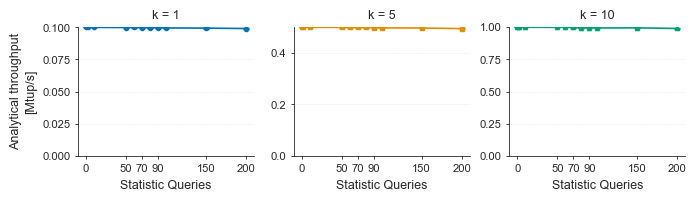

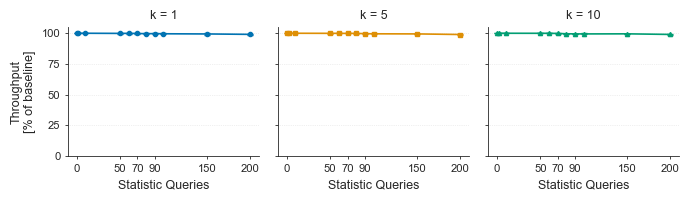

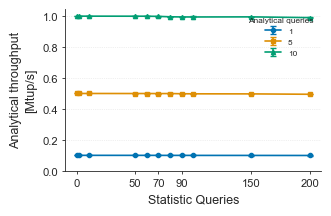

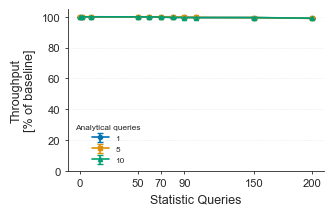

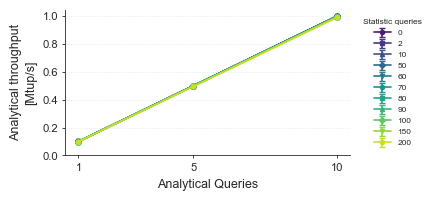

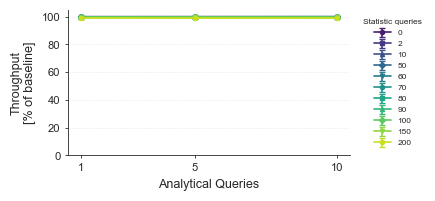

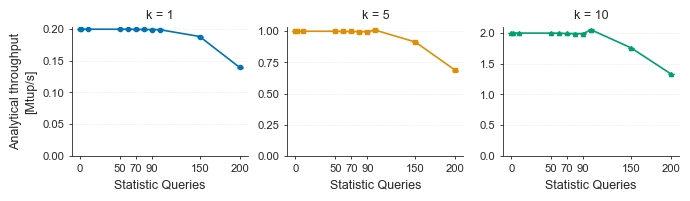

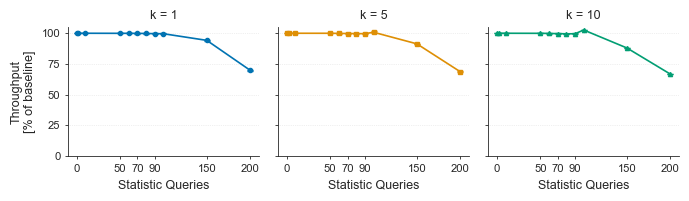

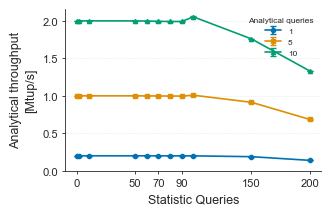

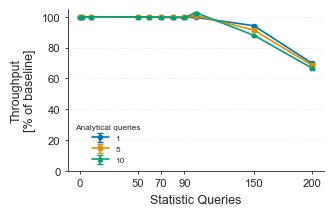

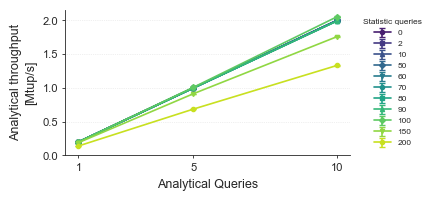

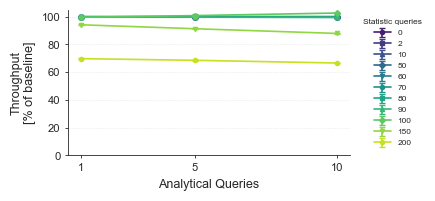

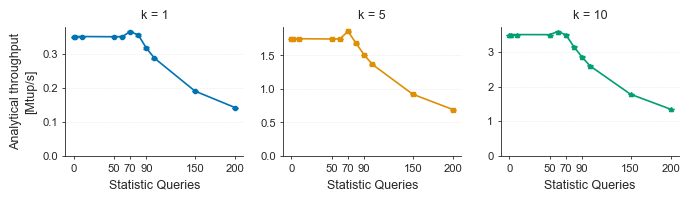

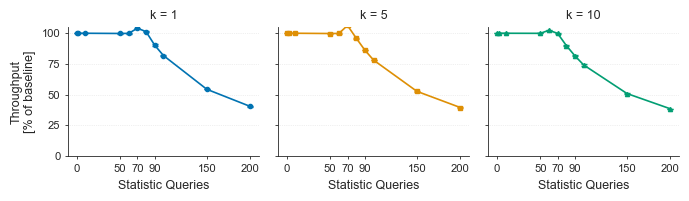

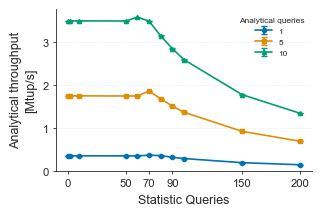

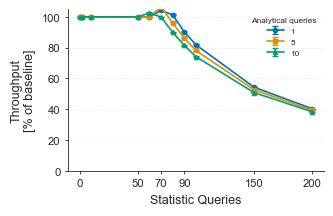

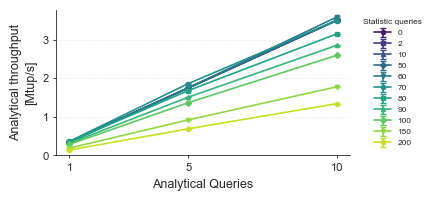

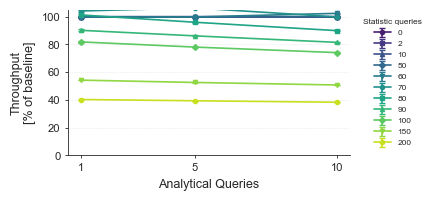

In [11]:
### (k, j) figure groups — emitted once per rate, so an over-capacity arm is never drawn on the same
### axes as a sub-saturation one. Metric is analytical throughput: mean_mtps is median-per-query x k,
### pct_of_baseline is relative to that (rate, k) cell's own j=0 arm.
def facet_by_k(rate, ycol, ecol, ylabel, name, sharey):
    """One subplot per analytical-query count, x = statistic queries."""
    a = agg[agg["tuples_per_sec_per_query"] == rate]
    ks = sorted(a["num_analytical_queries"].unique())
    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, axes = plt.subplots(1, len(ks), figsize=(FULL_W, 2.1), sharey=sharey, squeeze=False)
        for idx, (ax, k) in enumerate(zip(axes[0], ks)):
            d = a[a["num_analytical_queries"] == k].sort_values("num_statistic_queries")
            ax.errorbar(d["num_statistic_queries"], d[ycol], yerr=d[ecol],
                        marker=MARKERS[idx % len(MARKERS)], color=PALETTE[idx], capsize=2)
            ax.set_xlabel("Statistic Queries")
            ax.set_title(f"k = {k}")
            ax.set_xticks(J_TICKS)
            ax.set_ylim(0, 105) if ycol == "pct_of_baseline" else ax.set_ylim(bottom=0)
            style_axis(ax)
        axes[0][0].set_ylabel(ylabel)
        fig.tight_layout()
        FIGURES[name] = fig
        plt.show()


def hue_by_k(rate, ycol, ecol, ylabel, name):
    """Single axes, one line per analytical-query count, x = statistic queries."""
    a = agg[agg["tuples_per_sec_per_query"] == rate]
    ks = sorted(a["num_analytical_queries"].unique())
    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, ax = plt.subplots(figsize=(COL_W, 2.1))
        for idx, k in enumerate(ks):
            d = a[a["num_analytical_queries"] == k].sort_values("num_statistic_queries")
            ax.errorbar(d["num_statistic_queries"], d[ycol], yerr=d[ecol],
                        marker=MARKERS[idx % len(MARKERS)], color=PALETTE[idx], capsize=2,
                        label=f"{k}")
        ax.set_xlabel("Statistic Queries")
        ax.set_ylabel(ylabel)
        ax.set_xticks(J_TICKS)
        ax.set_ylim(0, 105) if ycol == "pct_of_baseline" else ax.set_ylim(bottom=0)
        style_axis(ax)
        ax.legend(frameon=False, title="Analytical queries", fontsize=6, title_fontsize=6)
        FIGURES[name] = fig
        plt.show()


def hue_by_j(rate, ycol, ecol, ylabel, name):
    """Axes swapped: x = analytical queries, one line per statistic-query count. j is an ORDERED
    quantity with many levels, so it gets a sequential palette — the categorical one used for k
    makes a monotone sweep read as unrelated categories."""
    a = agg[agg["tuples_per_sec_per_query"] == rate]
    js = sorted(a["num_statistic_queries"].unique())
    colors = sns.color_palette("viridis", len(js))
    with sns.plotting_context("paper", rc=PAPER_RC):
        # Wider than a bare column, and the legend goes OUTSIDE: with only 3 x positions there is no
        # empty corner big enough for 7 entries, and inside it lands on the j=200 series.
        fig, ax = plt.subplots(figsize=(COL_W * 1.35, 2.1))
        for idx, j in enumerate(js):
            d = a[a["num_statistic_queries"] == j].sort_values("num_analytical_queries")
            ax.errorbar(d["num_analytical_queries"], d[ycol], yerr=d[ecol],
                        marker=MARKERS[idx % len(MARKERS)], color=colors[idx], capsize=2,
                        label=f"{j}")
        ax.set_xlabel("Analytical Queries")
        ax.set_ylabel(ylabel)
        ax.set_xticks(KS)
        ax.set_ylim(0, 105) if ycol == "pct_of_baseline" else ax.set_ylim(bottom=0)
        style_axis(ax)
        ax.legend(frameon=False, title="Statistic queries", fontsize=6, title_fontsize=6,
                  loc="center left", bbox_to_anchor=(1.02, 0.5))
        fig.tight_layout()
        FIGURES[name] = fig
        plt.show()


MTPS_LABEL = "Analytical throughput\n[Mtup/s]"
PCT_LABEL = "Throughput\n[% of baseline]"

for _rate in RATES:
    _t = _rate_tag(_rate)
    # sharey=False for absolute throughput: k=1 sits ~10x below k=10, and a shared axis flattens the
    # k=1 panel onto the floor. sharey=True for percent, where every panel is near 100 and an
    # independent zoom per panel would make them silently non-comparable.
    facet_by_k(_rate, "mean_mtps", "std_mtps", MTPS_LABEL,
               f"StatisticGrid_facetK_mtps_{_t}", sharey=False)
    facet_by_k(_rate, "pct_of_baseline", "pct_std", PCT_LABEL,
               f"StatisticGrid_facetK_pct_{_t}", sharey=True)
    hue_by_k(_rate, "mean_mtps", "std_mtps", MTPS_LABEL, f"StatisticGrid_hueK_mtps_{_t}")
    hue_by_k(_rate, "pct_of_baseline", "pct_std", PCT_LABEL, f"StatisticGrid_hueK_pct_{_t}")
    # x=k with absolute throughput is near-trivially linear — offered load scales with k by
    # construction, so throughput must follow. The percent version is the informative half.
    hue_by_j(_rate, "mean_mtps", "std_mtps", MTPS_LABEL, f"StatisticGrid_hueJ_mtps_{_t}")
    hue_by_j(_rate, "pct_of_baseline", "pct_std", PCT_LABEL, f"StatisticGrid_hueJ_pct_{_t}")

In [12]:
SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)
if not FIGURES:
    print("no figures produced (no results found).")
for name, fig in FIGURES.items():
    for ext, kwargs in [("png", {"dpi": 300}), ("pdf", {})]:
        path = os.path.join(SAVE_DIR, f"{name}.{ext}")
        fig.savefig(path, bbox_inches="tight", pad_inches=0, **kwargs)
        print("saved:", os.path.abspath(path))

saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticGrid_sustained_100k.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticGrid_sustained_100k.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticGrid_sustained_200k.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticGrid_sustained_200k.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticGrid_sustained_350k.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticGrid_sustained_350k.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DI